# 08 · Compositional data analysis and Aitchison geometry

Show why compositional variables require log-ratio geometry: inspect raw compositions, zero handling, variation structure, ILR coordinates and Aitchison distances across groups.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_composition, analyze_pca
frame,dataset=load_tabular_demo(); comp_frame,comp=load_compositional_demo(); ilr=analyze_composition(comp,transform='ilr',replace_zeros=True); clr=analyze_composition(comp,transform='clr',replace_zeros=True)

## Raw composition profiles

findfont: Failed to find font weight semibold, now using 700.


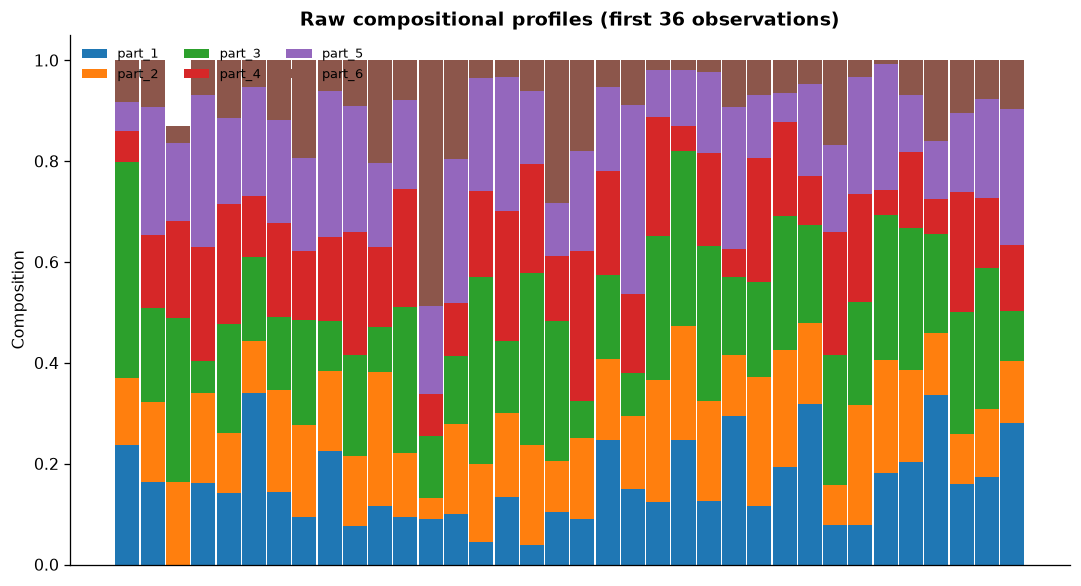

In [2]:
stacked_composition(comp_frame,n=36,title='Raw compositional profiles (first 36 observations)'); plt.show()

## Zero replacement diagnostics

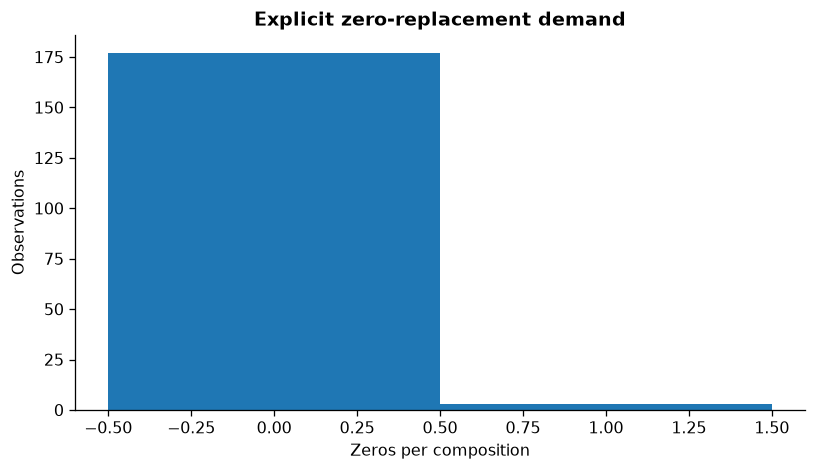

,source_row_index,zero_count,delta,replaced
2,2,1,0.024758,True
37,37,1,0.067521,True
115,115,1,0.084650,True


In [3]:
zr=ilr.zero_replacement; fig,ax=plt.subplots(figsize=(7.2,4.2)); ax.hist(zr.zero_count,bins=np.arange(zr.zero_count.max()+2)-0.5); ax.set_xlabel('Zeros per composition'); ax.set_ylabel('Observations'); ax.set_title('Explicit zero-replacement demand'); finish(fig); plt.show(); display(zr.query('replaced').head())

## Variation matrix

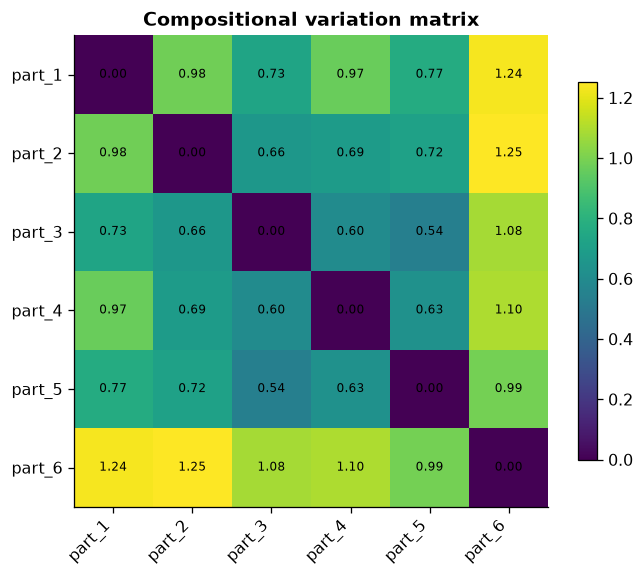

In [4]:
matrix_heatmap(ilr.variation_matrix,title='Compositional variation matrix'); plt.show()

## CLR feature structure

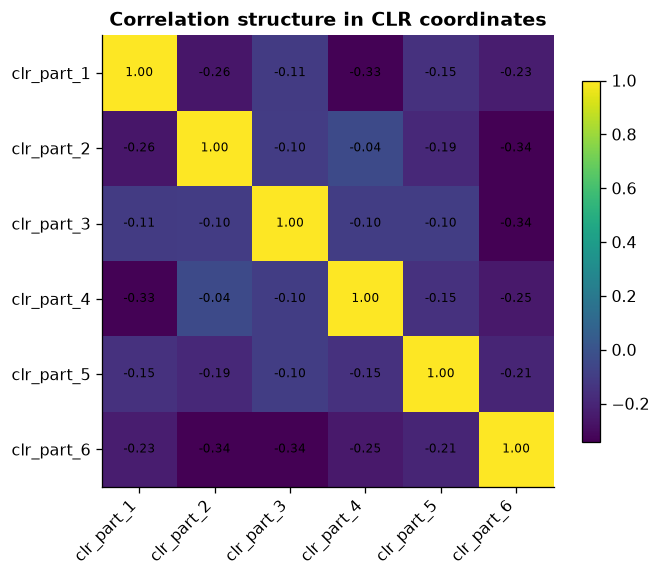

In [5]:
arr=clr.transformed.to_array(); corr=pd.DataFrame(np.corrcoef(arr,rowvar=False),index=clr.transformed.feature_names,columns=clr.transformed.feature_names); matrix_heatmap(corr,title='Correlation structure in CLR coordinates'); plt.show()

## ILR coordinates and PCA

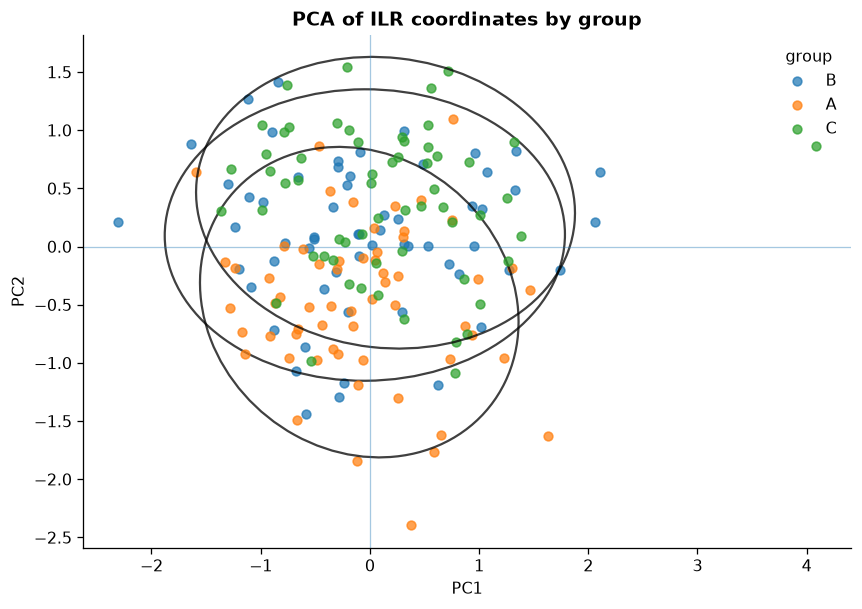

In [6]:
pca=analyze_pca(ilr.transformed,n_components=3,scaling='none'); score_plot(pca.scores,frame,x='PC1',y='PC2',group='group',title='PCA of ILR coordinates by group',ellipses=True); plt.show()

## Aitchison distances by group membership

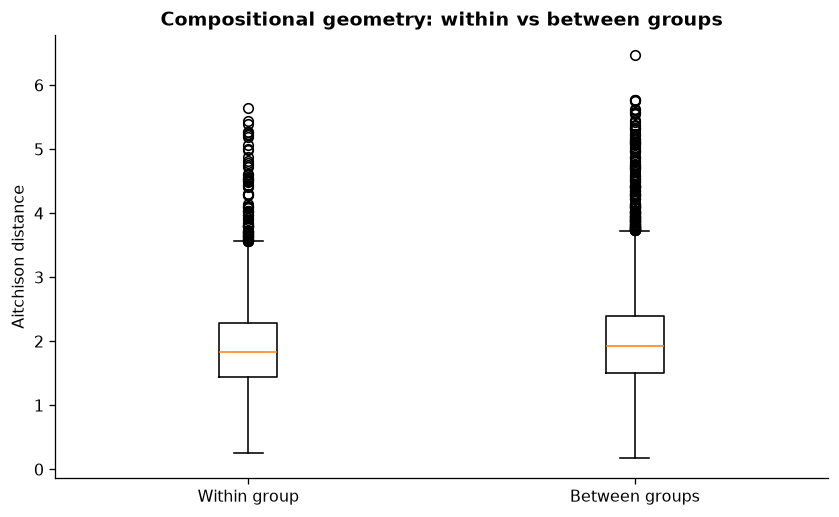

In [7]:
D=ilr.aitchison_distances; ids=list(D.index); groups=frame.set_index('id').loc[ids,'group']; within=[]; between=[]
for i in range(len(ids)):
  for j in range(i+1,len(ids)):
    (within if groups.iloc[i]==groups.iloc[j] else between).append(float(D.iloc[i,j]))
fig,ax=plt.subplots(figsize=(7.4,4.6)); labeled_boxplot(ax, [within,between], ['Within group','Between groups']); ax.set_ylabel('Aitchison distance'); ax.set_title('Compositional geometry: within vs between groups'); finish(fig); plt.show()